# Sample Demographics

> Descriptive summary of the study sample: **age**, **gender**, and
> **prior gaming experience** for every participant who completed the
> MATB explanation-form study.

**Why it matters.** The study is within-subjects (each participant sees all
three explanation forms F1/F2/F3), so demographics are not an experimental
factor — but they characterise *who* the effects generalise to and flag any
sampling skew worth noting in the write-up. Prior gaming experience is the one
demographic with a plausible link to the task: MATB is a multitasking flight
simulator, and comfort with real-time control could shift baseline performance.

This notebook reports **descriptive statistics and visualisations only** — no
inferential tests, since demographics here are context, not a hypothesis.

| Field | Coding |
|-------|--------|
| `age` | years |
| `gender` | m / f |
| `gaming_experience` | 1 = a lot · 2 = some · 3 = none |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

HERE = Path.cwd()
CSV = HERE / "HCAIStudyDemographicData.csv"

GAMING_LABELS = {1: "a lot", 2: "some", 3: "none"}
GENDER_LABELS = {"m": "male", "f": "female"}

## 1. Load and tidy

The raw CSV has a few cosmetic quirks (a trailing space in the `Age` header, a
long coded column name). We rename to tidy snake_case columns and attach
human-readable labels for the two categorical fields.

In [2]:
raw = pd.read_csv(CSV)
raw.columns = [c.strip() for c in raw.columns]

df = raw.rename(columns={
    "Scenario": "scenario",
    "Age": "age",
    "Gender": "gender",
    raw.columns[3]: "gaming_experience",
})
df["gender"] = df["gender"].str.strip().str.lower()
df["gaming_label"] = df["gaming_experience"].map(GAMING_LABELS)
df["gender_label"] = df["gender"].map(GENDER_LABELS)

print(f"N = {len(df)} participants")
df

N = 12 participants


,scenario,age,gender,gaming_experience,gaming_label,gender_label
0,1,26,m,2,some,male
1,2,41,f,3,none,female
2,3,38,m,2,some,male
3,4,51,f,1,a lot,female
4,5,18,f,3,none,female
5,6,19,f,2,some,female
6,7,35,f,1,a lot,female
7,8,39,m,3,none,male
8,9,32,f,3,none,female
9,10,40,m,2,some,male


## 2. Age

Central tendency and spread of participant age.

In [3]:
age = df["age"]
age_summary = pd.DataFrame({
    "n": [age.size],
    "mean": [age.mean()],
    "sd": [age.std()],
    "median": [age.median()],
    "min": [age.min()],
    "max": [age.max()],
}).round(2)
age_summary

,n,mean,sd,median,min,max
0,12,33.75,10.3,36.5,18,51


**Figure 1 — age distribution.** Histogram of participant age; the dashed line
marks the mean.

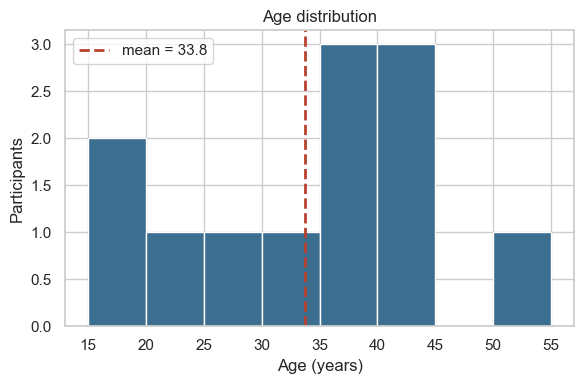

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
bins = np.arange(15, df["age"].max() + 6, 5)
ax.hist(df["age"], bins=bins, color="#3b6e8f", edgecolor="white")
ax.axvline(df["age"].mean(), color="#b8412e", linestyle="--", linewidth=2,
           label=f"mean = {df['age'].mean():.1f}")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Participants")
ax.set_title("Age distribution")
ax.legend()
fig.tight_layout()
fig.savefig(HERE / "demographics_age.png", dpi=150)
plt.show()

## 3. Gender and gaming experience

Counts for the two categorical fields.

In [5]:
gender_counts = (df["gender_label"].value_counts()
                 .rename_axis("gender").reset_index(name="n"))
gender_counts["%"] = (100 * gender_counts["n"] / len(df)).round(1)

gaming_counts = (df["gaming_experience"].value_counts().sort_index()
                 .rename(index=GAMING_LABELS)
                 .rename_axis("gaming_experience").reset_index(name="n"))
gaming_counts["%"] = (100 * gaming_counts["n"] / len(df)).round(1)

print("Gender\n", gender_counts.to_string(index=False))
print("\nGaming experience\n", gaming_counts.to_string(index=False))

Gender
 gender  n    %
  male  6 50.0
female  6 50.0

Gaming experience
 gaming_experience  n    %
            a lot  3 25.0
             some  5 41.7
             none  4 33.3


**Figure 2 — categorical breakdown.** Left: gender split. Right: prior gaming
experience (1 = a lot → 3 = none).

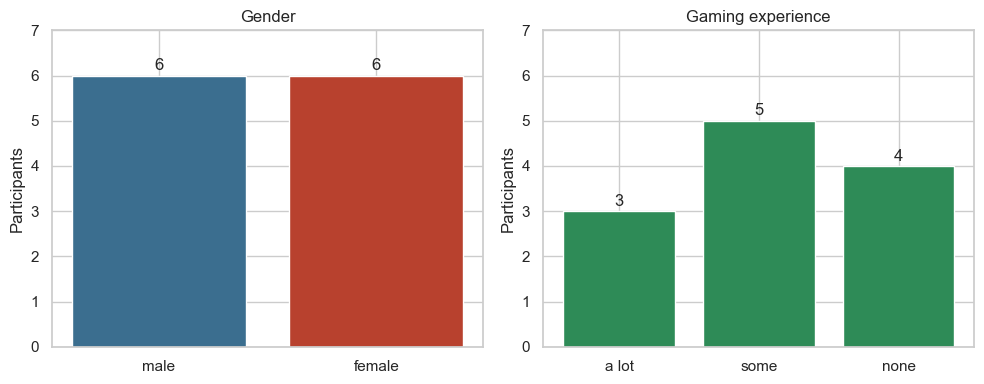

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

g = df["gender_label"].value_counts()
axes[0].bar(g.index, g.values, color=["#3b6e8f", "#b8412e"], edgecolor="white")
axes[0].set_title("Gender")
axes[0].set_ylabel("Participants")

order = ["a lot", "some", "none"]
gl = df["gaming_label"].value_counts().reindex(order).fillna(0)
axes[1].bar(gl.index, gl.values, color="#2e8b57", edgecolor="white")
axes[1].set_title("Gaming experience")
axes[1].set_ylabel("Participants")

for ax in axes:
    ax.set_ylim(0, max(g.max(), gl.max()) + 1)
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(i, v + 0.05, int(v), ha="center", va="bottom")

fig.tight_layout()
fig.savefig(HERE / "demographics_categorical.png", dpi=150)
plt.show()

## 4. Age by gaming experience

A quick look at whether age and prior gaming experience travel together in this
small sample — purely descriptive, given N.

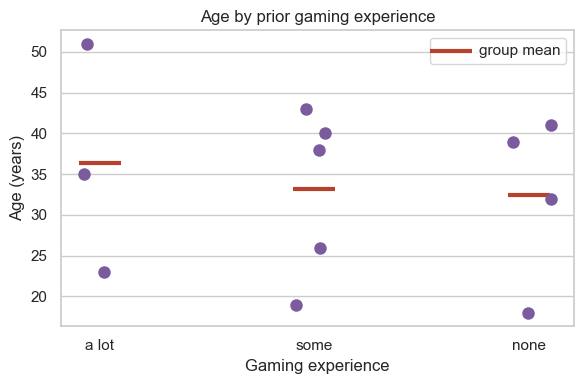

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
order = ["a lot", "some", "none"]
sns.stripplot(data=df, x="gaming_label", y="age", order=order,
              color="#7a5c9e", size=9, jitter=0.12, ax=ax)
means = df.groupby("gaming_label")["age"].mean().reindex(order)
ax.scatter(range(len(order)), means.values, marker="_", s=900,
           color="#b8412e", linewidths=3, label="group mean")
ax.set_xlabel("Gaming experience")
ax.set_ylabel("Age (years)")
ax.set_title("Age by prior gaming experience")
ax.legend()
fig.tight_layout()
fig.savefig(HERE / "demographics_age_by_gaming.png", dpi=150)
plt.show()

## 5. Compact summary

One tidy block suitable for the Participants paragraph of the report.

In [8]:
lines = [
    f"N = {len(df)} participants",
    f"Age: M = {df['age'].mean():.1f}, SD = {df['age'].std():.1f}, "
    f"range {df['age'].min()}–{df['age'].max()}",
    "Gender: " + ", ".join(f"{k} {v}" for k, v in
                           df['gender_label'].value_counts().items()),
    "Gaming experience: " + ", ".join(
        f"{lbl} {int((df['gaming_label'] == lbl).sum())}"
        for lbl in ["a lot", "some", "none"]),
]
print("\n".join(lines))

df.to_csv(HERE / "demographics_tidy.csv", index=False)

N = 12 participants
Age: M = 33.8, SD = 10.3, range 18–51
Gender: male 6, female 6
Gaming experience: a lot 3, some 5, none 4
